# <u>Neural Networks for Regression</u>

### Prerequisites:
* <a href="../../Supervised ML Basis.ipynb">Check out the notebook on Supervised ML Basics</a>

## Topics

* [1. Core idea](#idea)
* [**2.1 Regression**](#reg)
* [2.2 Classification](#class)
    * <a href="../../2.Classification/11.Artificial Neural Networks/Neural Networks for Classification.ipynb">Check out the notebook on Neural Networks for Classification</a>

* [Neural Networks for Regression library](#library)

    

In [3]:
import numpy as np  # for random numbers and numpy arrays
import pandas as pd # for dataframes
import matplotlib.pyplot as plt # for 2D Plots
import plotly.express as px # for 3D Plots
import plotly.graph_objects as go # for 3D Plots

# Neural network classes
import sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
#print(sklearn.__version__)

# Pytorch
import torch # Deep learning and neural networks
import torch.nn as nn
#print(torch.__version__)

# Tensorflow (Deep learning framework)
import tensorflow as tf # High-level neural network API
from tensorflow import keras 
#print(tf.__version__)

print("Setup complete")

Setup complete


<a class="anchor" id="perceptron"></a>

# 1. Preceptron

**The Perceptron is the basic computational unit for neural networks with only one single artificial neuron**

<p align="center">
<img src="pics/1.png" width="400"/>
</p>

- Input layer: $x_1,\ldots,x_p$ are the input features
- $w_1,\ldots,w_p$ are the weights with bias term $b$
- One output neuron: $f(x)=\tau(w_1x_1 + \ldots + w_px_p + b)=\tau(w^\top x + b)$ with acitivation function $\tau$ 

### Choices for activation functions:
- Identity function (Linear Regression)
$$
f(x)=\tau (w^\top x) = w^\top x 
$$

- Logistic function (Logistic Regression)
$$
f(x) = \tau(w^\top x) = \frac{1}{1+ \exp(-w^\top x)}
$$

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- A $p$-dimensional input vector $x$ is presented by $p$ nodes in the input layer
- Consider a perceptron with 3-dimensional input vector $x$
$$
f(x)=\tau(w_1x_1+w_2x_2 + w_3x_3 + b)
$$

<p align="center">
<img src="pics/2.png" width="150"/>
</p>


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- Weights $w$ are connected to edges from the input layer
- Since this is a perceptron there are as many weights as the dimension of the input vector
- The bias term $b$ is often not visualized as separate node

<p align="center">
<img src="pics/3.png" width="350"/>
</p>


</div>
</div>

---

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- To visualize the bias $b$ as a node  add a constant feature to the input vector $\tilde{x}=(1,x_1,\ldots,x_p)^\top$
- Add the bias $b$ to the weights vector $\tilde{w}=(b,w_1,\ldots,w_p)$

<p align="center">
<img src="pics/4.png" width="250"/>
</p>


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- Computation $\tau(w_1x_1+w_2x_2+w_3x_3 + b)$ with activation function $\tau$ is represented by the neuron in the output layer

<p align="center">
<img src="pics/5.png" width="350"/>
</p>


</div>
</div>

### A neuron performs a 2-step computation:

**1. Affine Transformation: Weighted sum of inputs plus the bias**
- The neuron first perfroms the affine transformation

<p align="center">
<img src="pics/6.png" width="350"/>
</p>

**2. Non-linear Activation: A non-linear transformation applied to the weighted sum**
- The neuron then perfroms the non-linear transformation

<p align="center">
<img src="pics/7.png" width="350"/>
</p>

Hypothesis space formed by a single neuron is $$\mathcal{H}=\left\{f:\mathbb{R}^p \rightarrow \mathbb{R} \mid f(x)=\tau \left(\sum_{j=1}^p w_j x_j + b\right), w \in \mathbb{R}^p, b \in \mathbb{R} \right\}$$


### Perceptron Optimization

Optimize by minimizing empirical risk $$\mathcal{R}_{\text{emp}}=\frac{1}{n} \sum_{i=1}^n \underbrace{L(y^{(i)},f(x^{(i)}))}_{\text{loss function}}$$

* For Regression tasks usually choose L2 loss as loss function $$L(y,f(x))=\frac{1}{2} (y-f(x))^2$$
* For Classification tasks usually choose Entropy /Bernoulli loss as loss function $$L(y,f(x)) = - \left(y\log(f(x))+(1-y)\log(1-f(x))\right)$$

- Both L2 loss and Entropy loss are convex so global minimum can be found e.g. with gradient descent

<a class="anchor" id="single"></a>

# 2. Single Hidden Layer Neural Networks (Multi-Layer Perceptron)

### Motivation

- Individual neurons can be used as building blocks of
more complicated functions
- Networks of neurons can represent extremely complex hypothesis
spaces

##### Example

**Since single neurons are restricted to learning only linear decision boundaries it perfroms poor on data that is not linearly separable**

<p align="center">
<img src="pics/8_.png" width="550"/>
</p>

**The neuron can easily separate the classes if the original features are transformed to a new feature space**

<p align="center">
<img src="pics/9_.png" width="700"/>
</p>

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- Add a single hidden layer to this Perceptron

<p align="center">
<img src="pics/10.png" width="300"/>
</p>


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- Single Hidden Layer leads to a more complex neural network

<p align="center">
<img src="pics/11.png" width="600"/>
</p>


</div>
</div>

**Single Hidden Layer networks consist of**
- an input layer
- a hidden layer that has a set of neurons
    - each neuron in the hidden layer perfroms a 2-step computation (affine transformation and then a non-linear transformation)
- an output layer that has at least one output neuron
    - each neuron in the Output layer perfroms a final 2-step computation (affine transformation and then a non-linear transformation)


#### Single Hidden Layer networks example

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/12_.png" width="550"/>
  <img src="pics/13_.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/14_.png" width="550"/>
  <img src="pics/15_.png" width="550"/>
</div>


<p align="center">
<img src="pics/16_.png" width="600"/>
</p>

---

<p align="center">
<img src="pics/17.png" width="600"/>
</p>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/18.png" width="550"/>
  <img src="pics/19.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/20.png" width="550"/>
</div>



### Many kinds of activation functions

**ReLU Activation function (Rectified linear unit):**
- Most popular activation function choice

$$
\sigma(v) = \max(0,v)
$$


**Sigmoid Activation function:**
- Usable even in the hidden layer
- Often used for binary classification outputs

$$
\sigma(v) = \frac{1}{1+\exp(-v)}
$$


**Hyperbolic Tangent Activation function:**
- Similar to sigmoid but centered around zero

$$
\sigma(v) = \tanh(v) = \frac{\sinh(v)}{\cosh(v)} = 1-\frac{2}{\exp(2v)+1}
$$


**Softmax Activation function:**
- Usually used in the output layer for multi-class classification
- Converts scores into probabilities that sum to 1

$$
\sigma(v_i) = \frac{\exp(v_i)}{\sum_j \exp(v_j)}
$$

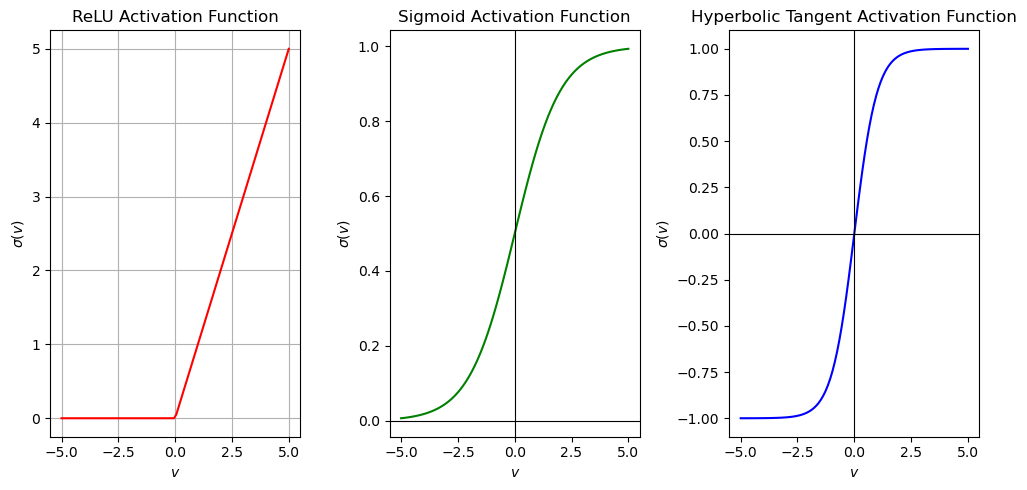

In [ ]:
n = 100
v = np.linspace(-5, 5, n)

ReLU = lambda v : np.maximum(0, v)
Sigmoid = lambda v : 1 / (1 + np.exp(-v))
tanh = lambda v : 1 - 2 / (np.exp(2*v)+1)

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.plot(v, ReLU(v),c="red")
plt.xlabel(r"$v$")
plt.ylabel(r"$\sigma(v)$")
plt.title("ReLU Activation Function")
plt.grid(True)


plt.subplot(1,3,2)
plt.plot(v, Sigmoid(v),c="green")
plt.xlabel(r"$v$")
plt.ylabel(r"$\sigma(v)$")
plt.title("Sigmoid Activation Function")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)


plt.subplot(1,3,3)
plt.plot(v, tanh(v),c="blue")
plt.xlabel(r"$v$")
plt.ylabel(r"$\sigma(v)$")
plt.title("Hyperbolic Tangent Activation Function")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)


plt.tight_layout()
plt.show()

<a class="anchor" id="one"></a>

# 4.1 Single hidden layer networks with one output neuron

**Single hidden layer networks with <u>one</u> Output neuron for Regression and binary classification**

- Input $x$ is a vector of shape $p \times 1$
- Collect all weights into a weight matrix $W$ of shape $p \times m$
$$
W = \begin{pmatrix} w_{1,1} & w_{1,2} & \ldots & w_{1,m} \\ 
w_{2,1} & w_{2,2} & \ldots & w_{2,m} \\
\vdots & \vdots & \ddots & \vdots \\
w_{p,1} & w_{p,2} & \ldots & w_{p,m}   
\end{pmatrix}
$$

- Obtain $z_1$ (neuron in hidden layer with bias term $b_1$) by picking the first column of $W$ which is $$W_1=\begin{pmatrix} w_{1,1} \\ w_{2,1} \\ \vdots \\ w_{p,1} \end{pmatrix}$$ and perform the affine transformation $W_1^\top x + b_1$ and then a non-linear transformation $\sigma(W_1^\top x + b_1)$ with the activation function $\sigma : \mathbb{R} \rightarrow \mathbb{R}$
- The single hidden layer networks with one output neuron has $m$ hidden neurons $z_1,\ldots,z_m$ in its hidden layer with $z_j = \sigma(W_j^\top x + b_j)$
    - $z_{\text{in},j}=W_j^\top x + b_j$ (affine transformation) for $j \in \{1,\ldots,m\}$
    - $z_{\text{out},j}=\sigma(z_{\text{in},j})=\sigma(W_j^\top x + b_j)$ (non-linear transformation) for $j \in \{1,\ldots,m\}$
- In vector notation it reads $z_{\text{in}}=(z_{\text{in},1},\ldots,z_{\text{in},m})^\top=W^\top x + b$ with $b=(b_1,\ldots,b_m)$
    - $z=z_{\text{out}}=\sigma(z_{\text{in}})=\sigma(W^\top x + b)$
    - the (hidden-layer) activation function $\sigma$ works element-wise on $z_{\text{in}}$
- For Regression or binary classification tasks with one output neuron the affine transformations in the hidden layer are computed as $f_{\text{in}}=u^\top z + c$ and the output is $f(x)=f_{\text{out}}=\tau(f_{\text{in}})=\tau(u^\top z + c)$ with output activation function $\tau$
    - For regression tasks $\tau$ is the identity function and for binary classification $\tau$ is the sigmoid function

&#128204; The hidden-layer activation function $\sigma$ is there to introduce non-linearities so the network can learn complex functions wheras $\tau$ is there to get the final score on the same scale as the target

- Multiple inputs
    - feed multiple inputs to a neural network simultaneously
    - Inputs $x^{(i)}$ for $i \in \{1,\ldots,n\}$ are collected as rows inside the desing matrix $X$ of shape $n \times p$
    - the affine transformation in the hidden layer is $XW + B$ with weights matrix $W$ of dimensions $p \times m$ and bias matrix B of dimensions $n \times m$ ($B$ contains the bias vector $b$ duplicated as rows)
    - the non-linear transformation is given by the matrix of hidden activations $Z=\sigma(XW + B)$ of dimensions $n \times m$
    - the final output of the output neuron contains predictions for each input $\tau(Zu + C)$ where $u$ is the vector of weights of the output neuron and $C$ of shape $n \times 1$ is a matrix whose elements are the bias $c$ of the output neuron


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/21.png" width="550"/>
  <img src="pics/22.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/23.png" width="550"/>
  <img src="pics/24.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/25.png" width="550"/>
</div>

---
<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/26.png" width="550"/>
  <img src="pics/27.png" width="550"/>
</div>

---
<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/28.png" width="550"/>
  <img src="pics/29.png" width="550"/>
</div>

---
<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/30.png" width="550"/>
  <img src="pics/31.png" width="550"/>
</div>


### Why Nonlinear Activations Are Essential

**If hidden layers do not contain nonlinear activation functions, the entire network collapses into a single linear model and can only learn linear decision boundaries**

$$
f(x)=\tau(u^\top  \sigma(W^\top x))
$$

If $\sigma$ is simply the identity function:

$$
f(x)=\tau(u^\top W^\top x)
$$

which can be rewritten as:

$$
f(x)=\tau(v^\top x)
$$

for some vector $v = Wu$. It can be seen that $f(x)$ can only yield a linear decision boundary.


<a class="anchor" id="multiple"></a>

# 4.2 Single hidden layer networks with multiple output neurons 

**Single hidden layer networks with <u>multiple</u> output neurons for multiclass classification**


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/32.png" width="550"/>
</div>

- Each neuron in the ouput layer represents a specific class so the number of neurons in the output layer is the number of classes
- $f=(f_1,\ldots,f_g)$ for $g$ output neurons
- Each of the $m$ hidden neurons $z_1,\ldots,z_m$ first compute the affine transformations $W_j^\top x$ (bias term omitted here) and then the non-linear transformations $z_j = \sigma(W_j^\top x), \quad \text{for } j = 1,\ldots,m \quad$ 
- Each output neuron first computes the affine transformations $f_{\text{in},k}=U_k^\top z$ where $z=(z_1,\ldots,z_m)^\top$ for every class $k=1,\ldots,g$ and then the non-linear transformations via the **softmax** activation function $$f_{\text{out},k}=\tau_k(f_{\text{in},k})=\frac{\exp(f_{\text{in},k})}{\sum_{k'=1}^g \exp(f_{\text{in},k'})}, \quad k=1,\ldots,g$$
- The softmax activation function gives a probability distribution (nonnegative and add up to 1) over the $g$ different classes
- Highest probability corresponds to predicted class

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/33.png" width="550"/>
</div>

--- 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/34.png" width="550"/>
  <img src="pics/35.png" width="550"/>
</div>

--- 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/36.png" width="550"/>
  <img src="pics/37.png" width="550"/>
</div>

--- 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/38.png" width="550"/>
  <img src="pics/39.png" width="550"/>
</div>

--- 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/40.png" width="550"/>
</div>


### Optimization: Softmax Loss

- The loss function for a softmax classifier is $$L(y,f(x))=-\sum_{k=1}^g [y=k] \log \left(\frac{\exp(f_{\text{in},k})}{\sum_{k'=1}^g \exp(f_{\text{in},k'})}\right) \quad \text{ where } [y=k] = \begin{cases} 1 &\text{ if }y=k, \\ 0 &\text{ otherwise} \end{cases}$$ 
- This equivalent to the cross-entropy loss when the label vector $y$ is one-hot encoded (e.g. $y=(0,1,0,0)^\top$)
- There is no analytical solution for the loss function for a softmax classifier


<a class="anchor" id="feedforward"></a>

# 4.3 Multi-layer feedforward networks (Deep neural network used in Deep Learning)

**Multi-layer feedforward networks with multiple hidden layers and output neurons.**
- Characterize Multi-layer feedforward networks by the following chain structure:
$$
f(x) = \tau \circ \phi \circ \sigma^{(l)} \circ \phi^{(l)} \circ \sigma^{(l-1)} \circ \phi^{(l-1)} \circ \ldots \circ \sigma^{(1)} \circ \phi^{(1)}
$$
- $\phi^{(i)}$ is the weighted sum (affine transformation) of hidden layer $i$
- $\sigma^{(i)}$ is the activation function (non-linear transformation) of hidden layer $i$
- $\phi$ is the the weighted sum (affine transformation) of the output layer
- $\tau$ is the the activation function (non-linear transformation) of the output layer
- Each hidden layer has an associated weights matrix $W^{(i)}$, bias $b^{(i)}$ and activation function $z^{(i)}$ for $i=1,\ldots,l$
- $z^{(i)}=\sigma^{(i)}(\phi^{(i)})=\sigma^{(i)}(W^{(i)^\top} z^{(i-1)} + b^{(i)})$ with $z^{(i-1)} $ being the previous hidden layer output and $z^{(0)}=x$
- If the activation functions $\sigma^{(i)}$ are linear then the entire network collapses into a single linear model and can only learn linear decision boundaries

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/41.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/43.png" width="550"/>
  <img src="pics/44.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/45.png" width="550"/>
  <img src="pics/46.png" width="550"/>
</div>


---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/47.png" width="550"/>
  <img src="pics/48.png" width="550"/>
</div>


---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/49.png" width="550"/>
  <img src="pics/50.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/51.png" width="550"/>
  <img src="pics/52.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/53.png" width="550"/>
  <img src="pics/54.png" width="550"/>
</div>

### Why add more hidden layers ?
- Multiple hidden layers allow more complex learning

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/42.png" width="550"/>
</div>

<a class="anchor" id="neural"></a>

# 8. Training Neural Networks

**Training consists of two repeated phases:**

### Forward Pass: Information flows through the network.
1. Input enters network
2. Hidden activations are computed
3. Output prediction is produced
4. Loss is computed

The loss measures prediction error.

### Backward Pass/Backpropogation: Information flows backward.

$\quad$**Goal: Determine how much each parameter contributed to the error.**

These contributions become gradients that tell us how to update weights.

<a class="anchor" id="loss"></a>

# 9. Loss Functions

**Regression**

$\quad$ Uses squared error: $$L(y,f(x))=\frac{1}{2}(y-f(x))^2$$

**Binary Classification**

$\quad$ Uses Bernoulli (cross-entropy) loss: $$L(y,f(x))=y\log(f(x))+(1-y)\log(1-f(x))$$

**The empirical risk over the training set is:** $$\mathcal{R}_\text{emp}=\sum_{i=1}^n L\left(y^{(i)},f(x^{(i)})\right)$$

Training attempts to minimize this quantity.

<a class="anchor" id="gradient"></a>

# 10. Gradient Descent

**Because neural network losses have no analytical solution, optimization uses gradient descent.**

Update rule: $$\theta^{[t+1]}=\theta^{[t]}-\alpha \nabla \mathcal{R}(\theta^{[t]})$$

where

- $\theta$ = all parameters
- $\alpha$ = learning rate (step size)
- $\nabla \mathcal{R}(\theta^{[t]})$ = gradient (direction of steepest ascent) at point $\theta^{[t]}$
- -$\nabla \mathcal{R}(\theta^{[t]})$ = direction of steepest descent at point $\theta^{[t]}$

<a class="anchor" id="SGD"></a>

# 11. Stochastic Gradient Descent (SGD)

Computing gradients over the entire dataset of size $n$ can be expensive.

Instead:

- randomly choose a minibatch (subset) of size $m$
- compute approximate gradient
- update parameters

One full pass through the dataset is called an epoch and consist of $\frac{n}{m}$ gradient updates.

**SGD algorithm:**
1. Initialize parameter vector $\theta^{[0]}$
2. $t \leftarrow 0$
3. <b>while</b> stopping criterion not met <b>do</b>
4. $\quad$ Randomly shuffle data and partition into minimatches $J_1,\ldots,J_K$ of size $m$
5. $\quad$ <b>for</b> $k \in \{1,\ldots,K\}$ <b>do</b>
6. $\quad$ $\quad$ $t \leftarrow t+1$
7. $\quad$ $\quad$ Compute gradient estimate with $J_k$:
7. $\quad$ $\quad$ $\quad$ $\hat{g}^{[t]} \leftarrow \frac{1}{m} \sum_{i \in J_k} \nabla_\theta L(y^{(i)},f(x^{(i)} \mid \theta^{[t-1]}))$
8. $\quad$ $\quad$ Apply update: $\theta^{[t]}=\theta^{[t-1]}-\alpha \hat{g}^{[t]}$
9. $\quad$ <b>end for</b>
10. <b>end while</b>

<a class="anchor" id="momentum"></a>

# 12. Momentum

**SGD can be slow. Momentum improves optimization by accumulating an exponentially weighted average of previous gradients.**

Benefits:
- faster convergence
- reduced oscillation
- smoother path through narrow valleys of the loss surface

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/55.png" width="550"/>
</div>

<a class="anchor" id="back"></a>

# 13. Backpropagation

### Backward pass/Backpropagation
- the information of the error that happened in the prediction of x flows backwards through the model
- calculate the error contribution of each weight to update weights by the negative gradient

Backpropagation is the algorithm used to efficiently compute gradients to update each weight $w \in \theta$ (and bias $b \in \mathbb{R}$).

>Backpropagation is simply the chain rule applied repeatedly on the weights which are stacked in layers inside the network.

### Backpropagation example (XOR example)
- randomly initialize weights $w$ and bias (usually bias is set to 0)
- as activations in both the hidden and output layers apply the logistic function $\frac{1}{1+\exp(-x)}$ for $\sigma$ and $\tau$
- feed the neural network with example $x=(1,0)^\top$ and $y=1$
- optimize the model using the squared error (L2 loss) between the binary 0-1 labels and the predicted probabilities (unusual in practice but easy computation)
- first compute Forward pass and get error of prediction
- compute the backward pass and apply backpropagation to update the weights using SGD $\left(\theta^{[t+1]}=\theta^{[t]}-\alpha \cdot \nabla_\theta L(y,f(x \mid \theta^{[t]}))\right)$
- Finally evaluate the model with our updated weights

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/56.png" width="550"/>
  <img src="pics/57.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/58.png" width="550"/>
  <img src="pics/59.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/60.png" width="550"/>
</div>

- The forwardpass predicted $f_\text{out}=0.7525$
- Compute the error of $f_\text{out}=0.7525$ and $y=1$
$$
\begin{align*}
L(y,f(x)) 
&= \frac{1}{2}\left(y-f(x^{(i)} \mid \theta)\right)^2 \\
&= \frac{1}{2} (y-f_\text{out})^2 \\
&= \frac{1}{2} (1-0.7525)^2 = 0.0306
\end{align*}
$$

**Backwardpass/Backward Propogation**
- reuse the results of the forward passwhich are her $z_{i,\text{in}},z_{i,\text{out}},f_{\text{in}} \text{ and }f_{\text{out}}$
- reuse the intermediate results during the backward pass due to the chain rule
- compute the derivatives of the activation functions and the affine transformations as well as $f_{\text{out}}$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/61.png" width="550"/>
  <img src="pics/62.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/63.png" width="550"/>
  <img src="pics/64.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/65.png" width="550"/>
  <img src="pics/66.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/67.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/68.png" width="550"/>
  <img src="pics/69.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/70.png" width="550"/>
  <img src="pics/71.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/72.png" width="550"/>
  <img src="pics/73.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/74.png" width="550"/>
  <img src="pics/75.png" width="550"/>
</div>


### Summary
- Our goal is to minimize the empirical risk  $\mathcal{R}_\text{emp}(\theta)=\frac{1}{n}\sum_{i=1}^n L(y^{(i)},f(x^{(i)} \mid \theta))$ with respect to the coefficients
- This is not possible since there is no way to find an analytical solution (global minimum) for deep neural networks
- Solve this by using gradient descent to iteratively find a local minimum of the loss function
- To perform gradient descent, we compute the gradient of the loss function Remp(θ) with respect to all the weights and biases in the 
- The number of components in the gradient is the total number of weights and biases in the network
- Apply the chainrule to the relevant portion of the computational graph to compute each component in the gradient
- In software implementations, a vectorized version of the chain rule is used to compute the derivatives with respect to multiple weights simultaneously
- After computing the gradient (using backpropagation), subtract the gradient (scaled by the learning-rate $\alpha$) from the current set of weights (and biases) which results in a new set of weights (and biases)
- The empirical loss for this new set of weights is now lower
- Next, once again compute the forward pass for this new set of weights and store the activations
- Then, compute the gradient of the empirical loss using backpropagation
- Repeat until the loss stops decreasing substantially
  - However, this naive approach often results in overfitting
  - Possible countermeasures include regularization and early stopping

<a class="anchor" id="example1"></a>

# 14. Example 1

**Single hidden-layer network with one output neuron for Regression**
$$
\begin{align*}
y(x)&=b_2 + W_2 \tanh(b_1 + W_1x) =
\begin{pmatrix} b_2 \\ b_2 \\ \vdots \\ b_2  \end{pmatrix} + W_2 \begin{bmatrix} \tanh((b_1 + W_1x)_1) \\ \tanh((b_1 + W_1x)_2)\\ \vdots \\ \tanh((b_1 + W_1x)_m)  \end{bmatrix}


\end{align*}
$$

Components
- Input vector $x \in \mathbb{R}^p$
- Weights matrix $W_1=\begin{pmatrix} w_{1,1} & w_{1,2} & \ldots & w_{1,p} \\ w_{2,1} & w_{2,2} & \ldots & w_{2,p} \\ \vdots & \vdots & \ddots & \vdots \\ w_{m,1} & w_{m,2} & \ldots & w_{m,p}   \end{pmatrix} \in \mathbb{R}^{m \times p}$  
- Bias vector $b_1 \in \mathbb{R}^m$
- Second weights matrix $W_2 \in \mathbb{R}^{k \times m}$
- Second bias vector $b_2 \in \mathbb{R}^k$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/76.jpg" width="550"/>
  <img src="pics/77.jpg" width="550"/>
</div>

---

**Multiple hidden-layer network with multiple output neuron**
$$
\begin{align*}
y(x)&=b_3 + W_3 \tanh(b_2 + W_2 \tanh(b_1 + W_1x)) 


\end{align*}
$$

Components
- Input vector $x \in \mathbb{R}^p$
- Weights matrix $W_1=\begin{pmatrix} w_{1,1} & w_{1,2} & \ldots & w_{1,p} \\ w_{2,1} & w_{2,2} & \ldots & w_{2,p} \\ \vdots & \vdots & \ddots & \vdots \\ w_{m,1} & w_{m,2} & \ldots & w_{m,p}   \end{pmatrix} \in \mathbb{R}^{m \times p}$  
- Bias vector $b_1 \in \mathbb{R}^m$
- Second weights matrix $W_2 \in \mathbb{R}^{k \times m}$
- Second bias vector $b_2 \in \mathbb{R}^k$
- Third weights matrix $W_3 \in \mathbb{R}^{r \times k}$
- Third bias vector $b_3 \in \mathbb{r}^r$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/78.jpg" width="550"/>
  <img src="pics/79.jpg" width="550"/>
</div>

### Forward pass:

```python
z1 = x                     # input layer              
z2 = np.tanh(b1 + W1 @ z1) # second layer (hidden)   
z3 = np.tanh(b2 + W2 @ z2) # third layer (hidden)    
z4 = b3 + W3 @ z3          # output layer
y  = z4                    # output
r  = y - t                 # residual
E  = 0.5 * r.T @ r         # suared error
```

### Parameters to be learned: $b_1, b_2, b_3, W_1, W_2, W_3$

$\quad \Rightarrow$ Compute gradient of $E$ with respect to those parameters

**Helper derivatives**

$$
\frac{d e^a}{d a} = e^a \frac{d}{d a} a \quad \text{ with Chain rule}  \\
\frac{d e^{(-a)}}{d a} = -e^{-a} \frac{d}{d a} a \quad \text{ with Chain rule}  \\
\frac{d (e^a + e^{-a})}{d a} = (e^a - e^{-a}) \frac{d}{d a} a \quad \text{ with Sum rule and Chain rule}  \\
\frac{d (e^a - e^{-a})}{d a} = (e^a + e^{-a}) \frac{d}{d a} a \quad \text{ with Sum rule and Chain rule}  \\
$$

**Derivative of $\tanh()$ scalar and vector version**

$$
\begin{align*}
\frac{d \tanh(a)}{d a} 
&= \frac{d }{d a} \frac{e^a - e^{-a}}{e^a + e^{-a}} \quad \mid \frac{d}{d a} \frac{u(a)}{v(a)} = \frac{\frac{d}{da}u(a)v(a) - u(a)\frac{d}{da}v(a)}{(v(a)^2)} \\
&= \frac{\frac{d }{d a}(e^a - e^{-a})(e^a + e^{-a}) - (e^a - e^{-a})\frac{d }{d a}(e^a + e^{-a})}{(e^a + e^{-a})^2} \\
&= \frac{(\frac{d }{d a}e^a - \frac{d }{d a}e^{-a})(e^a + e^{-a}) - (e^a - e^{-a})(\frac{d }{d a}e^a + \frac{d }{d a}e^{-a})}{(e^a + e^{-a})^2} \\
&= \frac{(e^a - e^{-a}(-\frac{d }{d a}a))(e^a + e^{-a}) - (e^a - e^{-a})(e^a + e^{-a}(-\frac{d }{d a}a))}{(e^a + e^{-a})^2} \\
&= \frac{(e^a + e^{-a}(\frac{d }{d a}a))(e^a + e^{-a}) - (e^a - e^{-a})(e^a - e^{-a}(\frac{d }{d a}a))}{(e^a + e^{-a})^2} \\
&= \frac{(e^a + e^{-a} \cdot 1)(e^a + e^{-a}) - (e^a - e^{-a})(e^a - e^{-a}\cdot 1)}{(e^a + e^{-a})^2} \\
&= \frac{(e^a + e^{-a})^2 - (e^a - e^{-a})^2}{(e^a + e^{-a})^2} \\
&= 1- \frac{(e^a - e^{-a})^2}{(e^a + e^{-a})^2} \\
&= 1- \tanh(a)^2 \quad \rightarrow \text{scalar version} \\

\text{For a vector }&v = (a_1, \ldots, a_d)^\top \\
\frac{d \tanh(a)}{d a} 
&= \frac{d}{d a} \begin{bmatrix} \tanh(a_1) \\ \vdots \\ \tanh(a_d) \end{bmatrix}  \\
&= \begin{bmatrix} \frac{d}{d a} \tanh(a_1) \\ \vdots \\ \frac{d}{d a} \tanh(a_d) \end{bmatrix}  \\
&= \begin{bmatrix} 1- \tanh(a_1)^2 \\ \vdots \\ 1- \tanh(a_d)^2 \end{bmatrix}  
= \text{Diag}(1-\tanh(v) \odot \tanh(v)) \quad \rightarrow \text{vector version}
\end{align*} 
$$

---

$$
\begin{align*}
\frac{\partial E}{\partial b_3} 
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial b_3} \quad \text{ since } b_3 \rightarrow y \rightarrow r \rightarrow E \\ 

&\frac{\partial E}{\partial r} = \frac{\partial }{\partial r} \frac{1}{2} r^\top r = \frac{1}{2} \frac{\partial }{\partial r} r^\top r = 2 \frac{1}{2} r = r  \\ 
&\frac{\partial r}{\partial y} = \frac{\partial }{\partial y} y-t = 1 \\
&\frac{\partial y}{\partial b_3} = \frac{\partial }{\partial b_3} z_4 = \frac{\partial }{\partial b_3} b_3 + W_3 z_3 = 1 \\
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial b_3}  \\
&= r \cdot 1 \cdot 1 = r
\end{align*}
$$



$$
\begin{align*}
\frac{\partial E}{\partial W_3} 
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial W_3} \quad \text{ since } W_3 \rightarrow y \rightarrow r \rightarrow E \\ 

&\frac{\partial E}{\partial r} = \frac{\partial }{\partial r} \frac{1}{2} r^\top r = \frac{1}{2} \frac{\partial }{\partial r} r^\top r = 2 \frac{1}{2} r = r  \\ 
&\frac{\partial r}{\partial y} = \frac{\partial }{\partial y} y-t = 1 \\
&\frac{\partial y}{\partial W_3} = \frac{\partial }{\partial W_3} z_4 = \frac{\partial }{\partial W_3} b_3 + W_3 z_3 = z_3 \\
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial b_3}  \\
&= r \cdot 1 \cdot z_3^\top = rz_3^\top
\end{align*}
$$

---

$$
\begin{align*}
\frac{\partial E}{\partial b_2} 
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial b_2}  \quad \text{ since } b_2 \rightarrow z_3 \rightarrow y \rightarrow r \rightarrow E \\ 

&\frac{\partial E}{\partial r} = \frac{\partial }{\partial r} \frac{1}{2} r^\top r = \frac{1}{2} \frac{\partial }{\partial r} r^\top r = 2 \frac{1}{2} r = r  \\ 
&\frac{\partial r}{\partial y} = \frac{\partial }{\partial y} y-t = 1 \\
&\frac{\partial y}{\partial z_3} = \frac{\partial }{\partial z_3} z_4 = \frac{\partial }{\partial z_3} b_3 + W_3 z_3 = W_3 \\
&\frac{\partial z_3}{\partial b_2} = \frac{\partial z_3}{\partial a_3} \frac{\partial a_3}{\partial b_2} =\text{Diag}(1-z_3^2) \cdot 1 \quad \text{ since }z_3 = \tanh(a_3), a_3 = b_2 + W_2z_2 \\
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial b_2}  \\
&= \text{Diag}(1-z_3^2)W_3^\top r
\end{align*}
$$




$$
\begin{align*}
\frac{\partial E}{\partial W_2} 
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial W_2}  \quad \text{ since } W_2 \rightarrow z_3 \rightarrow y \rightarrow r \rightarrow E \\ 

&\frac{\partial E}{\partial r} = \frac{\partial }{\partial r} \frac{1}{2} r^\top r = \frac{1}{2} \frac{\partial }{\partial r} r^\top r = 2 \frac{1}{2} r = r  \\ 
&\frac{\partial r}{\partial y} = \frac{\partial }{\partial y} y-t = 1 \\
&\frac{\partial y}{\partial z_3} = \frac{\partial }{\partial z_3} z_4 = \frac{\partial }{\partial z_3} b_3 + W_3 z_3 = W_3 \\
&\frac{\partial z_3}{\partial W_2} = \frac{\partial z_3}{\partial a_3} \frac{\partial a_3}{\partial W_2} =\text{Diag}(1-z_3^2) z_2 \quad \text{ since }z_3 = \tanh(a_3), a_3 = b_2 + W_2z_2 \\
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial W_2}  \\
&= \text{Diag}(1-z_3^2)W_3^\top r z_2^\top
\end{align*}
$$



---

$$
\begin{align*}
\frac{\partial E}{\partial b_1} 
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial z_2} \frac{\partial z_2}{\partial b_1}  \quad \text{ since } b_1 \rightarrow z_2 \rightarrow z_3 \rightarrow y \rightarrow r \rightarrow E \\ 
&\frac{\partial E}{\partial r} = \frac{\partial }{\partial r} \frac{1}{2} r^\top r = \frac{1}{2} \frac{\partial }{\partial r} r^\top r = 2 \frac{1}{2} r = r  \\ 
&\frac{\partial r}{\partial y} = \frac{\partial }{\partial y} y-t = 1 \\
&\frac{\partial y}{\partial z_3} = \frac{\partial }{\partial z_3} z_4 = \frac{\partial}{\partial z_3} b_3 + W_3 z_3 = W_3 \\
&\frac{\partial z_3}{\partial z_2} = \frac{\partial z_3}{\partial a_3} \frac{\partial a_3}{\partial z_2} =\text{Diag}(1-z_3^2)W_2 \quad \text{ since }z_3 = \tanh(a_3), a_3 = b_2 + W_2z_2 \\
&\frac{\partial z_2}{\partial b_1} = \frac{\partial z_2}{\partial a_2} \frac{\partial a_2}{\partial b_1} = \text{Diag}(1-z_2^2) \cdot 1 \quad \text{ since }z_2 = \tanh(a_2), a_2 = b_1 + W_1z_1 \\
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial z_2} \frac{\partial z_2}{\partial b_1}  \\
&= \text{Diag}(1-z_2^2)W_2^\top \text{Diag}(1-z_3^2)W_3^\top r
\end{align*}
$$

$$
\begin{align*}
\frac{\partial E}{\partial W_1} 
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial z_2} \frac{\partial z_2}{\partial W_1}  \quad \text{ since } W_1 \rightarrow z_2 \rightarrow z_3 \rightarrow y \rightarrow r \rightarrow E \\ 
&\frac{\partial E}{\partial r} = \frac{\partial }{\partial r} \frac{1}{2} r^\top r = \frac{1}{2} \frac{\partial }{\partial r} r^\top r = 2 \frac{1}{2} r = r  \\ 
&\frac{\partial r}{\partial y} = \frac{\partial }{\partial y} y-t = 1 \\
&\frac{\partial y}{\partial z_3} = \frac{\partial }{\partial z_3} z_4 = \frac{\partial}{\partial z_3} b_3 + W_3 z_3 = W_3 \\
&\frac{\partial z_3}{\partial z_2} = \frac{\partial z_3}{\partial a_3} \frac{\partial a_3}{\partial z_2} =\text{Diag}(1-z_3^2)W_2 \quad \text{ since }z_3 = \tanh(a_3), a_3 = b_2 + W_2z_2 \\
&\frac{\partial z_2}{\partial W_1} = \frac{\partial z_2}{\partial a_2} \frac{\partial a_2}{\partial W_1} = \text{Diag}(1-z_2^2) z_1 \quad \text{ since }z_2 = \tanh(a_2), a_2 = b_1 + W_1z_1 \\
&= \frac{\partial E}{\partial r} \frac{\partial r}{\partial y} \frac{\partial y}{\partial z_3} \frac{\partial z_3}{\partial z_2} \frac{\partial z_2}{\partial b_1}  \\
&= \text{Diag}(1-z_2^2)W_2^\top \text{Diag}(1-z_3^2)W_3^\top r z_1^\top
\end{align*}
$$

---

$$
\begin{align}
\nabla_{b_3} E
&= r \\[6pt]

\nabla_{W_3} E
&= r\, z_3^{\top} \\[6pt]

\nabla_{b_2} E
&= \color{green}\operatorname{Diag}\!\left(1-z_3^2\right)\, W_3^{\top}\, r\color{white} \\[6pt]

\nabla_{W_2} E
&= \color{green}\operatorname{Diag}\!\left(1-z_3^2\right)\, W_3^{\top}\, r\color{white}\, z_2^{\top} \\[6pt]

\nabla_{b_1} E
&= \color{orange}\operatorname{Diag}\!\left(1-z_2^2\right)\,
   W_2^{\top}\,
   \operatorname{Diag}\!\left(1-z_3^2\right)\,
   W_3^{\top}\,
   r\color{white} \\[6pt]

\nabla_{W_1} E
&= \color{orange}\operatorname{Diag}\!\left(1-z_2^2\right)\,
   W_2^{\top}\,
   \operatorname{Diag}\!\left(1-z_3^2\right)\,
   W_3^{\top}\,
   r\color{white}\,
   z_1^{\top}
\end{align}
$$

### Backward pass with Gradient Descent:


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

$$
b_1 = b_1 - \text{learning\_rate} \cdot \frac{\partial E}{\partial b_1} \\[2 mm]
W_1 = W_1 - \text{learning\_rate} \cdot \frac{\partial E}{\partial W_1} \\[2 mm]
$$


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

$$
b_2 = b_2 - \text{learning\_rate} \cdot \frac{\partial E}{\partial b_2} \\[2 mm]
W_2 = W_2 - \text{learning\_rate} \cdot \frac{\partial E}{\partial W_2} \\[2 mm]
$$

</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

$$
b_3 = b_3 - \text{learning\_rate} \cdot \frac{\partial E}{\partial b_3} \\[2 mm]
W_3 = W_3 - \text{learning\_rate} \cdot \frac{\partial E}{\partial W_3} \\
$$

</div>
</div>

In [ ]:
np.random.seed(1300)

# Network dimensions
p = 2   # input dimension
m = 4   # hidden layer 1
k = 3   # hidden layer 2
r = 1   # output dimension

learning_rate = 0.01

# Parameters
W1 = np.random.randn(m, p) * 0.1
b1 = np.zeros(m)

W2 = np.random.randn(k, m) * 0.1
b2 = np.zeros(k)

W3 = np.random.randn(r, k) * 0.1
b3 = np.zeros(r)


# Training sample
x = np.array([0.5, -1.2])
t = np.array([1.0])


# Training loop
for epoch in range(1000):

    # Forward pass
    z1 = x

    a2 = b1 + W1 @ z1
    z2 = np.tanh(a2)

    a3 = b2 + W2 @ z2
    z3 = np.tanh(a3)

    z4 = b3 + W3 @ z3

    y = z4

    r_vec = y - t

    E = 0.5 * r_vec.T @ r_vec


    # Backward pass

    # dE/db3 = r
    dE_db3 = r_vec

    # dE/dW3 = r z3^T
    dE_dW3 = np.outer(r_vec, z3)

    # dE/db2
    dE_db2 = (1.0 - z3**2) * (W3.T @ r_vec)

    # dE/dW2
    dE_dW2 = np.outer(dE_db2, z2)

    # dE/db1
    dE_db1 = (1.0 - z2**2) * (W2.T @ dE_db2)

    # dE/dW1
    dE_dW1 = np.outer(dE_db1, z1)


    # Gradient descent update
    b1 -= learning_rate * dE_db1
    W1 -= learning_rate * dE_dW1

    b2 -= learning_rate * dE_db2
    W2 -= learning_rate * dE_dW2

    b3 -= learning_rate * dE_db3
    W3 -= learning_rate * dE_dW3

    if epoch % 100 == 0:
        print(f"epoch={epoch:4d}  loss={E:.6f}")

print("\nPrediction:")
print(y)
print("Target:")
print(t)

epoch=   0  loss=0.504296
epoch= 100  loss=0.056672
epoch= 200  loss=0.005670
epoch= 300  loss=0.000530
epoch= 400  loss=0.000048
epoch= 500  loss=0.000004
epoch= 600  loss=0.000000
epoch= 700  loss=0.000000
epoch= 800  loss=0.000000
epoch= 900  loss=0.000000

Prediction:
[0.99999272]
Target:
[1.]


0 27.31200063687443
500 0.07743590914430139
1000 0.07554259273487711
1500 0.07399393778492024


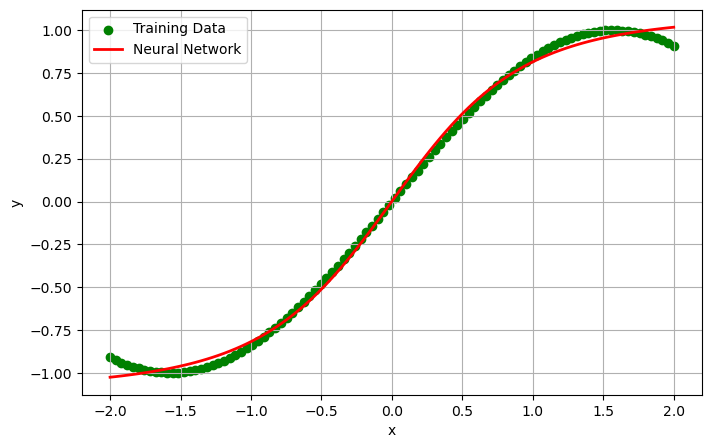

In [ ]:
np.random.seed(1300)

# Network dimensions
p = 1   # input dimension
m = 4   # hidden layer 1
k = 3   # hidden layer 2
r = 1   # output dimension

learning_rate = 0.01

# Parameters
W1 = np.random.randn(m, p) * 0.1
b1 = np.zeros(m)

W2 = np.random.randn(k, m) * 0.1
b2 = np.zeros(k)

W3 = np.random.randn(r, k) * 0.1
b3 = np.zeros(r)


X = np.linspace(-2, 2, 100).reshape(-1, 1)

# nonlinear target function
T = np.sin(X)

for epoch in range(2000):

    total_loss = 0

    for x, t in zip(X, T):

        z1 = x

        a2 = b1 + W1 @ z1
        z2 = np.tanh(a2)

        a3 = b2 + W2 @ z2
        z3 = np.tanh(a3)

        y = b3 + W3 @ z3

        r_vec = y - t
        E = 0.5 * r_vec.T @ r_vec

        total_loss += E

        # backprop
        dE_db3 = r_vec
        dE_dW3 = np.outer(r_vec, z3)

        dE_db2 = (1 - z3**2) * (W3.T @ r_vec)
        dE_dW2 = np.outer(dE_db2, z2)

        dE_db1 = (1 - z2**2) * (W2.T @ dE_db2)
        dE_dW1 = np.outer(dE_db1, z1)

        # update
        b1 -= learning_rate * dE_db1
        W1 -= learning_rate * dE_dW1

        b2 -= learning_rate * dE_db2
        W2 -= learning_rate * dE_dW2

        b3 -= learning_rate * dE_db3
        W3 -= learning_rate * dE_dW3

    if epoch % 500 == 0:
        print(epoch, total_loss)

Y_pred = []

for x in X:

    z1 = x

    a2 = b1 + W1 @ z1
    z2 = np.tanh(a2)

    a3 = b2 + W2 @ z2
    z3 = np.tanh(a3)

    y = b3 + W3 @ z3

    Y_pred.append(y.item())

Y_pred = np.array(Y_pred)

plt.figure(figsize=(8,5))
plt.scatter(X, T, label="Training Data",color="green")

plt.plot(X, Y_pred,linewidth=2,label="Neural Network",color="red")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()

<a class="anchor" id="example2"></a>

# 15. Example 2

Consider following multiple hidden-layer neural network with on output neuron

$$
y=f_3(w_3, f_2(w_2,f_1(w_1,x))) 
$$

- $x$ and $y$ are scalars
- $w_1,w_2,w_3$ are parameters to be learned
- Evaluate with squarred loss $E=\frac{1}{2}(y-t)^2$
- Goal: Minimize $E$ with respect to $w_1,w_2,w_3$ so $\underset{w_1,w_2,w_3}{\min}E$
- Choose $f_i(w_i,z_i)=\tanh(w_iz_i)$

```python
z1 = x               # input layer              
z2 = tanh(w1*z1)     # second layer (hidden)   
z3 = tanh(w2*z2)     # third layer (hidden)    
z4 = tanh(w3*z3)     # output layer
r  = z4 - t          # residual
E  = 0.5 * r.T @ r   # suared error
```

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/80_.png" width="700"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/81.png" width="700"/>
</div>

$$
\begin{align*}
\frac{\partial E}{\partial E} &= 1 \\
\frac{\partial E}{\partial z_4} &= z_4-t = r \\
\end{align*}
$$

$$
\begin{align*}
\frac{\partial E}{\partial w_3} &= \frac{\partial E}{\partial z_4} \frac{\partial z_4}{\partial w_3} = r(1-z_4^2)z_3  \\
\frac{\partial E}{\partial z_3} &= \frac{\partial E}{\partial z_4} \frac{\partial z_4}{\partial z_3} = r(1-z_4^2)w_3  \\
\end{align*}
$$

$$
\begin{align*}
\frac{\partial E}{\partial w_2} &= \frac{\partial E}{\partial z_3} \frac{\partial z_3}{\partial w_2}=r(1-z_4^2)w_3(1-z_3^2)z_2  \\
\frac{\partial E}{\partial z_2} &= \frac{\partial E}{\partial z_3} \frac{\partial z_3}{\partial z_2}=r(1-z_4^2)w_3(1-z_3^2)w_2  \\
\end{align*}
$$

$$
\begin{align*}
\frac{\partial E}{\partial w_1} &= \frac{\partial E}{\partial z_2} \frac{\partial z_2}{\partial w_1}=r(1-z_4^2)w_3(1-z_3^2)w_2(1-z_2^2)z_1  \\
\end{align*}
$$

**Gradient updates**
$$
w_3 \leftarrow w_3 - \eta \frac{\partial E}{\partial w_3}, \quad
w_2 \leftarrow w_2 - \eta \frac{\partial E}{\partial w_2}, \quad
w_1 \leftarrow w_1 - \eta \frac{\partial E}{\partial w_1} \\
$$

In [ ]:
np.random.seed(1848)

w1 = np.random.randn()
w2 = np.random.randn()
w3 = np.random.randn()

def forward(x, t, w1, w2, w3):
    z1 = x
    z2 = np.tanh(w1 * z1)
    z3 = np.tanh(w2 * z2)
    z4 = np.tanh(w3 * z3)
    r = z4 - t
    E = 0.5 * r**2

    return z1, z2, z3, z4, r, E


def backward(x, t, w1, w2, w3, lr=0.1):
    z1, z2, z3, z4, r, E = forward(x, t, w1, w2, w3)
    sub1 = r * (1 - z4**2)
    dEdw3 = sub1 * z3
    sub2 = (1 - z3**2)
    dEdw2 = sub1 * w3 * sub2 * z2
    dEdw1 = sub1 * w3 * sub2 * w2 * (1 - z2**2) * z1

    w3 -= lr * dEdw3
    w2 -= lr * dEdw2
    w1 -= lr * dEdw1
    return w1, w2, w3, E

x = 0.5
t = 1.0

for epoch in range(1000):
    w1, w2, w3, E = backward(x, t, w1, w2, w3)
    if epoch % 100 == 0:
        print(epoch, E)

0 0.5000720214863305
100 0.49952416626609797
200 0.4946294369771923
300 0.061757127188732594
400 0.007527811623547166
500 0.0036837970638847802
600 0.0024018992765618328
700 0.0017717238946525708
800 0.0013995509412624359
900 0.0011547265769411262


In [ ]:
np.random.seed(1848)

# Network dimension
p = 3

# Weight matrices
W1 = np.random.randn(p, p)
W2 = np.random.randn(p, p)
W3 = np.random.randn(p, p)

# Single training sample
x = np.random.randn(p)
t = np.random.randn(p)


def forward(x, t, W1, W2, W3):

    z1 = x
    z2 = np.tanh(W1 @ z1)
    z3 = np.tanh(W2 @ z2)
    z4 = np.tanh(W3 @ z3)
    r = z4 - t
    E = 0.5 * (r @ r)
    return z1, z2, z3, z4, r, E


def backward(x, t, W1, W2, W3, lr=0.01):
    z1, z2, z3, z4, r, E = forward(x, t, W1, W2, W3)

    # Output layer delta
    delta4 = r * (1.0 - z4**2)

    # Hidden layer deltas
    delta3 = (W3.T @ delta4) * (1.0 - z3**2)
    delta2 = (W2.T @ delta3) * (1.0 - z2**2)

    # Weight gradients
    dEdW3 = np.outer(delta4, z3)
    dEdW2 = np.outer(delta3, z2)
    dEdW1 = np.outer(delta2, z1)

    # Gradient descent
    W3 -= lr * dEdW3
    W2 -= lr * dEdW2
    W1 -= lr * dEdW1

    return W1, W2, W3, E


# Training loop
for epoch in range(1000):

    W1, W2, W3, E = backward(x, t,W1, W2, W3,lr=0.01)

    if epoch % 100 == 0:
        print(f"epoch={epoch:4d}, loss={E:.6f}")


# Final prediction
z1, z2, z3, z4, r, E = forward(x, t,W1, W2, W3)

print("\nPrediction:")
print(z4)

print("\nTarget:")
print(t)

print("\nFinal loss:")
print(E)

epoch=   0, loss=1.105589
epoch= 100, loss=0.584248
epoch= 200, loss=0.306463
epoch= 300, loss=0.172139
epoch= 400, loss=0.127838
epoch= 500, loss=0.110286
epoch= 600, loss=0.101376
epoch= 700, loss=0.095973
epoch= 800, loss=0.092323
epoch= 900, loss=0.089683

Prediction:
[-0.40270821 -0.96255166  0.09956169]

Target:
[-0.43250642 -1.38020368  0.105998  ]

Final loss:
0.08768128446393347


<a class="anchor" id="example3"></a>

# 16. Example 3

Consider following multiple hidden-layer neural network with one output neuron.

$$
f(w,x)=\frac{1}{1+\exp(-(w_0x_0+w_1x_1+w_2))}
$$

- $a=w_0x_0$
- $b=w_1x_1$
- $c=a+b$
- $d=c+w_2$
- $e=-d$
- $f=\exp(e)$
- $g=1+f$
- $y=\frac{1}{g}$

- With binary cross-entropy loss $E=-(t \log(y) + (1-t) \log(1-y))$

### Forward pass

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/82.png" width="700"/>
</div>

$$
\begin{align*}
\frac{\partial E}{\partial w_0} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial c}\frac{\partial c}{\partial a}\frac{\partial a}{\partial w_0} \\


\frac{\partial E}{\partial w_1} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial c}\frac{\partial c}{\partial b}\frac{\partial b}{\partial w_1} \\


\frac{\partial E}{\partial w_2} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial w_2} \\
\end{align*}
$$

---

$$\frac{\partial E}{\partial y} = \frac{\partial}{\partial y}(-(t \log(y) + (1-t) \log(1-y))) = -\frac{t}{y} + \frac{1-t}{1-y}$$
$$\frac{\partial y}{\partial g} = \frac{\partial}{\partial g}\frac{1}{g} = -\frac{1}{g^2}$$
$$\frac{\partial g}{\partial f} = \frac{\partial}{\partial f}1+f = 1$$
$$\frac{\partial f}{\partial e} = \frac{\partial}{\partial e}\exp(e) = \exp(e) = f$$
$$\frac{\partial e}{\partial d} = \frac{\partial}{\partial d}-d = -1$$
$$\frac{\partial d}{\partial c} = \frac{\partial}{\partial c}c+w_2 = 1$$
$$\frac{\partial d}{\partial w_2} = \frac{\partial}{\partial c}c+w_2 = 1$$
$$\frac{\partial c}{\partial a} = \frac{\partial}{\partial a}a+b = 1$$
$$\frac{\partial c}{\partial b} = \frac{\partial}{\partial a}a+b = 1$$
$$\frac{\partial a}{\partial w_0} = \frac{\partial}{\partial w_0}w_0x_0 = x_0$$
$$\frac{\partial b}{\partial w_1} = \frac{\partial}{\partial w_1}w_1x_1 = x_1$$


---

$$
\begin{align*}
\frac{\partial E}{\partial w_0} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial c}\frac{\partial c}{\partial a}\frac{\partial a}{\partial w_0} \\
&= (-\frac{t}{y} + \frac{1-t}{1-y})(-\frac{1}{g^2})(1)f(-1)(1)(1)x_0 \\
&=(-\frac{t}{y} + \frac{1-t}{1-y})\frac{f}{g^2}x_0  \\
((y = \frac{1}{g} \iff g = \frac{1}{y}) \text{ und } (g = 1+f &\iff f = g-1)) \Rightarrow f = \frac{1}{y} - 1 = \frac{1-y}{y}\quad\text{und}\quad  
\frac{f}{g^2} = \frac{\frac{1-y}{y}}{\frac{1}{y^2}}&=y(1-y) \\
&=(-\frac{t}{y} + \frac{1-t}{1-y})y(1-y)x_0  \\
&=(-\frac{t}{y}y(1-y) + \frac{1-t}{1-y}y(1-y))x_0  \\
&=(-t(1-y) + (1-t)y)x_0  \\
&=(-t+ty + y-ty)x_0  \\
&=(y-t)x_0  \\
\end{align*}
$$

$$
\begin{align*}
\frac{\partial E}{\partial w_1} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial c}\frac{\partial c}{\partial b}\frac{\partial b}{\partial w_1} \\
&=(-\frac{t}{y} + \frac{1-t}{1-y})(-\frac{1}{g^2})(1)f(-1)(1)(1)x_1 \\
&=(-\frac{t}{y} + \frac{1-t}{1-y})(\frac{f}{g^2})x_1 \\
&=(y-t)x_1 \\
\end{align*}
$$

$$
\begin{align*}
\frac{\partial E}{\partial w_2} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial w_2} \\
&=(-\frac{t}{y} + \frac{1-t}{1-y})(-\frac{1}{g^2})(1)f(-1)(1) \\
&=(-\frac{t}{y} + \frac{1-t}{1-y})(\frac{f}{g^2}) \\
&=y-t \\
\end{align*}
$$

### Backward pass
<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/83.png" width="700"/>
</div>

**There is a much simpler derivative**

Because
$$
y = \sigma(d) = \frac{1}{1+\exp(-d)}
$$
and
$$
E=-(t \log(y) + (1-t) \log(1-y))
$$
the sigmoid and binary cross-entropy combine beautifully.
First,
$$
\frac{\partial E}{\partial y} = -\frac{t}{y} + \frac{1-t}{1-y}.
$$
Also,
$$
\frac{\partial y}{\partial d} = y(1-y).
$$
Multiplying:
$$
\frac{\partial E}{\partial d}=(-\frac{t}{y} + \frac{1-t}{1-y})y(1-y)
$$
Everything simplifies to
$$
\frac{\partial E}{\partial d}=y-t
$$
This is one of the most important identities in machine learning.

#### Final gradients

Since

$$
d=w_0x_0+w_1x_1+w_2
$$

we have

$$
\frac{d}{d w_0}=x_0, \quad \frac{d}{d w_1}=x_1, \quad \frac{d}{d w_2}=1
$$

Therefore

$$
\frac{\partial E}{\partial w_0}=(y-t)x_0 \\[1.5 mm]
\frac{\partial E}{\partial w_1}=(y-t)x_1 \\[1.5 mm]
\frac{\partial E}{\partial w_2}=y-t \\
$$


In [ ]:
np.random.seed(2013)

def forward_pass(w,x):
    w0,w1,w2 = w
    x0,x1 = x

    a = w0*x0
    b = w1*x1
    c = a + b
    d = c + w2
    e = -d
    f = np.exp(e)
    g = 1 + f
    y = 1/g
    E = -(t*np.log(y)+(1-t)*np.log(1-y))
     


def backward_pass():

    pass

\frac{\partial E}{\partial x_1} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial c}\frac{\partial c}{\partial b}\frac{\partial b}{\partial x_1} \\

\frac{\partial E}{\partial x_0} &= \frac{\partial E}{\partial y}\frac{\partial y}{\partial g}\frac{\partial g}{\partial f}\frac{\partial f}{\partial e}\frac{\partial e}{\partial d}\frac{\partial d}{\partial c}\frac{\partial c}{\partial a}\frac{\partial a}{\partial x_0} \\

